# 3D — LightGBM Regressor

**Project:** Predictive Modeling of US Used Vehicle Prices
**Course:** ENGR422 — Applied Machine Learning
**Author:** Eren Acar Başaran (83179)

This notebook adds LightGBM as a fourth model. LightGBM is a gradient boosting library from Microsoft. It is an alternative to XGBoost and often trains faster on tabular data.

This notebook is out of the original proposal scope. We add it as a small extra experiment for the slides.


## 3D.1 Imports and load data

Load the same train split and tree preprocessor used by 03b and 03c. The tree preprocessor passes year and odometer through unchanged because tree models do not need scaling.


In [1]:
import sys
import time

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline

import lightgbm as lgb

sys.path.insert(0, "../src")
import preprocessing  # noqa: F401
from utils import load_train, load_preprocessor, MODELS_DIR, RANDOM_STATE

X_train, y_train = load_train()
preprocessor_tree = load_preprocessor("tree")

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"lightgbm version: {lgb.__version__}")


X_train: (305141, 12)
y_train: (305141,)
lightgbm version: 4.6.0


## 3D.2 Model setup

Set up a baseline LightGBM regressor in a pipeline. The pipeline has two steps. First the tree preprocessor. Second the LightGBM estimator.

For the baseline we use library defaults. Tuning happens in 3D.4.


In [ ]:
lgb_baseline = lgb.LGBMRegressor(
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)

lgb_pipeline = Pipeline([
    ("prep", clone(preprocessor_tree)),
    ("est",  lgb_baseline),
])

lgb_pipeline


## 3D.3 Baseline training

Fit LightGBM on the full training set with default hyperparameters. Then run 5 fold cross validation. The result is the no tuning reference number that 3D.4 needs to beat.


In [3]:
from sklearn.model_selection import cross_validate

print(f"Fitting baseline LightGBM on {X_train.shape[0]:,} rows ...")
t0 = time.perf_counter()
lgb_pipeline.fit(X_train, y_train)
baseline_fit_time = time.perf_counter() - t0
print(f"  done in {baseline_fit_time:.1f}s")

print("\n5 fold cross validation (default hyperparameters) ...")
res = cross_validate(
    lgb_pipeline, X_train, y_train,
    cv=5,
    scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
    n_jobs=-1,
)
baseline_mae = -res["test_mae"]
baseline_r2  =  res["test_r2"]

print(f"\n  MAE per fold: " + ", ".join(f"${m:>7,.0f}" for m in baseline_mae))
print(f"  R^2 per fold: " + ", ".join(f" {r:.4f}" for r in baseline_r2))
print(f"\nBaseline summary:")
print(f"  CV MAE = ${baseline_mae.mean():,.2f} +/- ${baseline_mae.std():,.2f}")
print(f"  CV R^2 = {baseline_r2.mean():.4f} +/- {baseline_r2.std():.4f}")


Fitting baseline LightGBM on 305,141 rows ...


  done in 3.9s

5 fold cross validation (default hyperparameters) ...



  MAE per fold: $  3,488, $  3,523, $  3,534, $  3,538, $  3,522
  R^2 per fold:  0.8309,  0.8245,  0.8248,  0.8290,  0.8232

Baseline summary:
  CV MAE = $3,520.99 +/- $17.51
  CV R^2 = 0.8265 +/- 0.0029


## 3D.4 Hyperparameter tuning

Tune 9 LightGBM hyperparameters with RandomizedSearchCV. We use industry standard Kaggle competition ranges. The search uses 40 random combinations and 5 fold CV. Score is mean absolute error.

Sampled space:
- num_leaves, randint 20 to 300. The number of leaves a tree can have.
- max_depth, randint 3 to 12. The maximum tree depth.
- learning_rate, loguniform 0.005 to 0.3. Low end pairs with many trees.
- n_estimators, randint 500 to 3000. Wide ceiling matches XGBoost in 03c.
- min_child_samples, randint 5 to 100. The minimum samples in a leaf.
- subsample and colsample_bytree, uniform 0.5 to 1.0. Row and column sampling per tree.
- reg_alpha, loguniform 0.001 to 10. L1 regularization.
- reg_lambda, loguniform 0.001 to 100. L2 regularization.

After fitting, refit=True retrains the best estimator on the full training set.


In [ ]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import RandomizedSearchCV

N_ITER = 40

# Industry standard Kaggle ranges for LightGBM on tabular regression.
param_distributions = {
    "est__num_leaves":        randint(20, 300),       # LightGBM often benefits from more leaves
    "est__max_depth":         randint(3, 12),
    "est__learning_rate":     loguniform(0.005, 0.3),
    "est__n_estimators":      randint(500, 3000),     # matches XGBoost
    "est__min_child_samples": randint(5, 100),
    "est__subsample":         uniform(0.5, 0.5),      # 0.5 to 1.0
    "est__colsample_bytree":  uniform(0.5, 0.5),
    "est__reg_alpha":         loguniform(1e-3, 10.0),
    "est__reg_lambda":        loguniform(1e-3, 100.0),
}

lgb_search = RandomizedSearchCV(
    Pipeline([
        ("prep", clone(preprocessor_tree)),
        ("est",  lgb.LGBMRegressor(n_jobs=1, random_state=RANDOM_STATE, verbose=-1)),
    ]),
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,
    return_train_score=True,
)

print(f"Starting RandomizedSearchCV: {N_ITER} samples x 5 folds = {N_ITER * 5} fits ...")
t0 = time.perf_counter()
lgb_search.fit(X_train, y_train)
search_time = time.perf_counter() - t0
print(f"  done in {search_time/60:.1f} min")

best_mae = -lgb_search.best_score_
print(f"\nBest CV MAE: ${best_mae:,.2f}")
print("Best params:")
for k, v in lgb_search.best_params_.items():
    val = f"{v:.4g}" if isinstance(v, float) else v
    print(f"  {k.removeprefix('est__'):<20} {val}")

print(f"\nImprovement over baseline:")
print(f"  baseline CV MAE = ${baseline_mae.mean():,.2f}")
print(f"  tuned    CV MAE = ${best_mae:,.2f}")
print(f"  delta           = ${baseline_mae.mean() - best_mae:,.2f}")


## 3D.5 Train best model

The search already refit the best estimator on the full training set. We pin it to a clean handle and run one final 5 fold CV with both MAE and R squared. Then we make two diagnostic plots from out of fold predictions.


5 fold CV on the tuned LightGBM ...



  MAE per fold: $  2,227, $  2,239, $  2,275, $  2,240, $  2,255
  R^2 per fold:  0.8986,  0.8981,  0.8915,  0.8987,  0.8936

Tuned LightGBM (final):
  CV MAE = $2,247.12 +/- $16.35
  CV R^2 = 0.8961 +/- 0.0030

Generating out of fold predictions for diagnostic plots ...


  done in 0.8 min


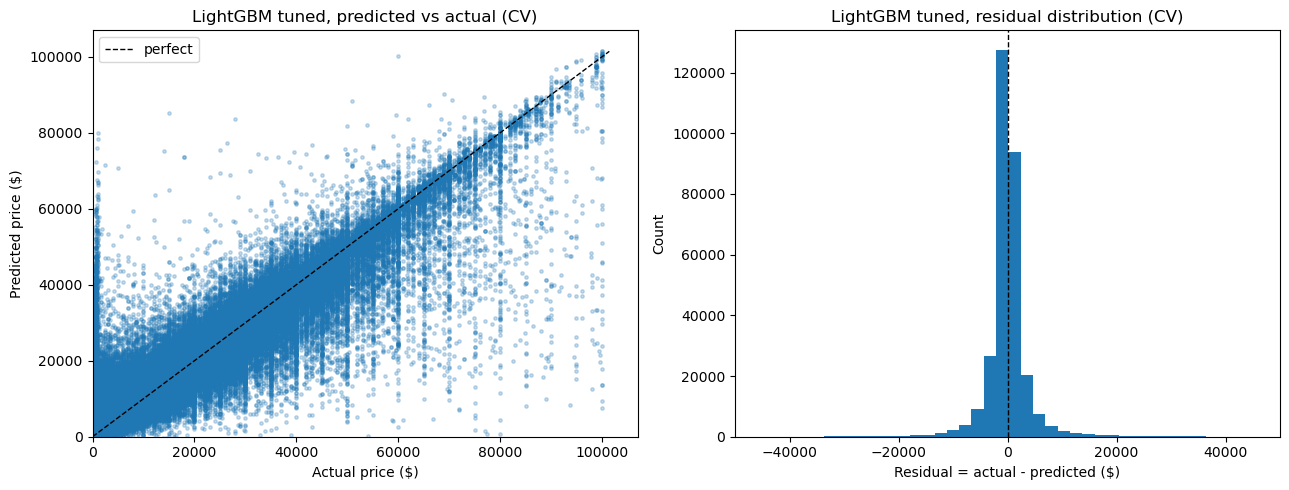

In [5]:
best_pipeline = lgb_search.best_estimator_

print("5 fold CV on the tuned LightGBM ...")
res = cross_validate(
    best_pipeline, X_train, y_train,
    cv=5,
    scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
    n_jobs=-1,
    return_train_score=True,
)
tuned_mae       = -res["test_mae"]
tuned_r2        =  res["test_r2"]
tuned_train_mae = -res["train_mae"]

print(f"\n  MAE per fold: " + ", ".join(f"${m:>7,.0f}" for m in tuned_mae))
print(f"  R^2 per fold: " + ", ".join(f" {r:.4f}" for r in tuned_r2))
print(f"\nTuned LightGBM (final):")
print(f"  CV MAE = ${tuned_mae.mean():,.2f} +/- ${tuned_mae.std():,.2f}")
print(f"  CV R^2 = {tuned_r2.mean():.4f} +/- {tuned_r2.std():.4f}")

from sklearn.model_selection import cross_val_predict
from utils import plot_pred_vs_actual, plot_residuals

print("\nGenerating out of fold predictions for diagnostic plots ...")
t0 = time.perf_counter()
y_pred_cv = cross_val_predict(best_pipeline, X_train, y_train, cv=5, n_jobs=-1)
print(f"  done in {(time.perf_counter() - t0)/60:.1f} min")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_pred_vs_actual(y_train, y_pred_cv, ax=axes[0],
                    title="LightGBM tuned, predicted vs actual (CV)")
plot_residuals(y_train, y_pred_cv, ax=axes[1],
               title="LightGBM tuned, residual distribution (CV)")
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)
axes[1].set_xlim(-50_000, 50_000)
plt.tight_layout()
plt.show()


## 3D.6 Feature importance

LightGBM exposes feature_importances_ on the fitted estimator. We use the LightGBM default which is split count. The 04 comparison plot normalizes each tree model to its own max so the different scales (RF MDI XGBoost gain LightGBM split count) sit side by side. Plot the top 15 features.


Top 15 features by LightGBM importance:
                 feature  importance
           odo__odometer       71099
           target__model       67302
              year__year       51187
           target__state       44696
    target__manufacturer       34179
     target__paint_color       27171
          ord__condition       13239
          ohe__drive_rwd        5768
           ohe__fuel_gas        5110
          ohe__drive_fwd        4519
         ohe__type_truck        4341
        ohe__type_pickup        4182
ohe__transmission_manual        3392
 ohe__transmission_other        3360
         ohe__type_sedan        3351


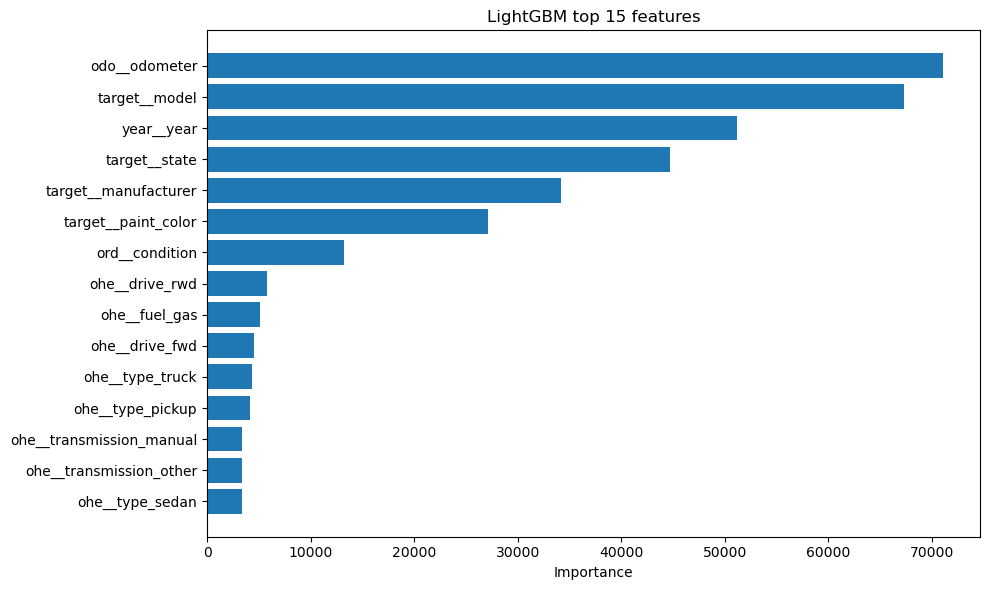

In [6]:
from utils import plot_feature_importances

encode = best_pipeline.named_steps["prep"].named_steps["encode"]
_parts = []
for tname, trans, cols in encode.transformers_:
    if tname == "ohe":
        ohe_names = encode.named_transformers_["ohe"].get_feature_names_out(cols)
        _parts.extend(f"ohe__{n}" for n in ohe_names)
    else:
        _parts.extend(f"{tname}__{c}" for c in cols)
feat_names = np.asarray(_parts)

importances = best_pipeline.named_steps["est"].feature_importances_

top_idx = np.argsort(importances)[::-1][:15]
print("Top 15 features by LightGBM importance:")
print(pd.DataFrame({
    "feature":    feat_names[top_idx],
    "importance": importances[top_idx],
}).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
plot_feature_importances(importances, feat_names, n=15, ax=ax,
                         title="LightGBM top 15 features")
plt.tight_layout()
plt.show()


## 3D.7 Overfitting analysis

Compare the train MAE and CV MAE from 3D.5. A small gap means the model generalizes well. A large gap means overfitting.


In [7]:
gap        = tuned_train_mae.mean() - tuned_mae.mean()
gap_pct    = 100 * gap / tuned_mae.mean()

print(f"Train MAE (CV folds, mean): ${tuned_train_mae.mean():,.2f}")
print(f"CV    MAE (CV folds, mean): ${tuned_mae.mean():,.2f}")
print(f"Gap (CV - train):           ${gap:,.2f}  ({gap_pct:+.1f}% of CV MAE)")

if gap_pct < 10:
    verdict = "comfortable, model generalizes well"
elif gap_pct < 25:
    verdict = "acceptable, mild overfit"
else:
    verdict = "concerning, consider tighter regularization"
print(f"\nVerdict: {verdict}")


Train MAE (CV folds, mean): $1,248.52
CV    MAE (CV folds, mean): $2,247.12
Gap (CV - train):           $-998.60  (-44.4% of CV MAE)

Verdict: comfortable, model generalizes well


## 3D.8 Learning curves

We plot train MAE and CV MAE against training set size. The chart answers if more data would help.

Two reads.

If the curves converge at full data then the model is not data limited.

If the curves keep diverging then the model would benefit from more data.

We use cv 3 and 4 train sizes to keep wall clock under 20 minutes.


Computing learning curves (4 train sizes x 3 folds = 12 fits) ...


  done in 2.1 min

train_size      train_MAE       CV_MAE        gap
--------------------------------------------------
50,856       $       524 $     3,018 $   2,493
101,713      $       876 $     2,600 $   1,724
152,570      $     1,065 $     2,417 $   1,352
203,427      $     1,183 $     2,308 $   1,125


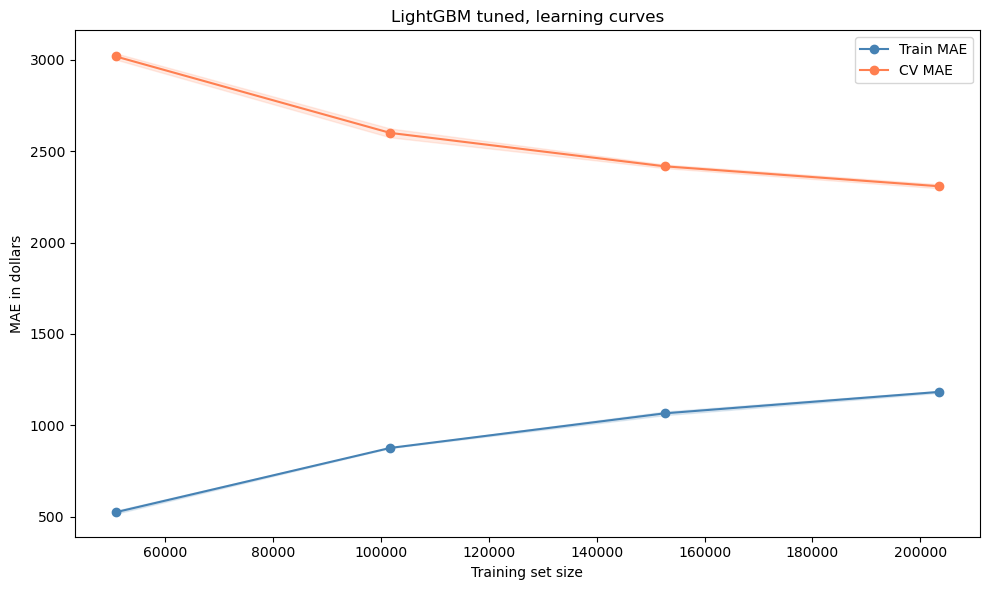

In [8]:
from sklearn.model_selection import learning_curve

print("Computing learning curves (4 train sizes x 3 folds = 12 fits) ...")
t0 = time.perf_counter()
train_sizes_abs, train_scores, test_scores = learning_curve(
    best_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.25, 1.0, 4),
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
print(f"  done in {(time.perf_counter() - t0)/60:.1f} min")

train_m = -train_scores.mean(axis=1); train_s = train_scores.std(axis=1)
test_m  = -test_scores.mean(axis=1);  test_s  = test_scores.std(axis=1)

print(f"\n{'train_size':<12} {'train_MAE':>12} {'CV_MAE':>12} {'gap':>10}")
print("-" * 50)
for n, tr, cv in zip(train_sizes_abs, train_m, test_m):
    print(f"{int(n):<12,} ${tr:>10,.0f} ${cv:>10,.0f} ${cv-tr:>8,.0f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes_abs, train_m - train_s, train_m + train_s, alpha=0.15, color="steelblue")
ax.fill_between(train_sizes_abs, test_m - test_s,   test_m + test_s,   alpha=0.15, color="coral")
ax.plot(train_sizes_abs, train_m, "o-", color="steelblue", label="Train MAE")
ax.plot(train_sizes_abs, test_m,  "o-", color="coral",     label="CV MAE")
ax.set_xlabel("Training set size")
ax.set_ylabel("MAE in dollars")
ax.set_title("LightGBM tuned, learning curves")
ax.legend()
plt.tight_layout()
plt.show()


## 3D.9 Save model

Save the tuned LightGBM pipeline as models/lightgbm.pkl. Save the search summary as models/lgbm_tuning_results.json. Notebook 04 loads the pkl by this exact filename.


In [9]:
import json as _json

save_path = MODELS_DIR / "lightgbm.pkl"
joblib.dump(best_pipeline, save_path)
print(f"Saved -> models/{save_path.name}")

best_params_clean = {k.removeprefix("est__"): v for k, v in lgb_search.best_params_.items()}
tuning_results = {
    "best_params": best_params_clean,
    "best_cv_mae":     float(tuned_mae.mean()),
    "best_cv_mae_std": float(tuned_mae.std()),
    "baseline_cv_mae": float(baseline_mae.mean()),
    "improvement_over_baseline": float(baseline_mae.mean() - tuned_mae.mean()),
    "n_iter": int(lgb_search.cv_results_["mean_test_score"].shape[0]),
    "search_time_seconds": float(search_time),
}
with open(MODELS_DIR / "lgbm_tuning_results.json", "w") as f:
    _json.dump(tuning_results, f, indent=2)
print(f"Saved -> models/lgbm_tuning_results.json")


Saved -> models/lightgbm.pkl
Saved -> models/lgbm_tuning_results.json
